# **Baseline model - Xây dựng mô hình cơ sở**
Trước khi đi vào huấn luyện các model phức tạp, chúng tôi cần một cơ sở tốt làm cột mốc so sánh với các mô hình phức tạp sau này
Vì vậy, notebooks này sẽ tập trung chủ yếu huấn luyện mô hình đơn giản nhất, ít chi phí nhất rồi tối ưu bằng nhiều phương pháp
- Xác định bài toán, lựa chọn mô hình
- Train mô hình với dữ liệu thô
- Cải thiện mô hình qua features engineering
- Cải thiện mô hình qua các thông số đầu vào

**Mục tiêu:** Đưa ra một mô hình dự đoán cơ sở tối ưu nhất và ít chi phí nhất

**Mục lục:**
1. [Thiết lập và cài đặt](#1)
2. [Xác định bài toán](#2)
3. [Huấn luyện mô hình](#3)
4. [Đánh giá và so sánh](#4)

<a id = '1'></a>

## 1. Thiếp lập và cài đặt
Nhập thư viện cần thiết và kết nối database `datathon.duckdb`

In [1]:
# Thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys, os
sys.path.append(os.path.abspath('..'))
from src.get_data import get_connection
from src.baseline_models import seasonal_naive_model, linear_regression_model

In [2]:
# Kết nối database
conn = get_connection()

[OKE] Kết nối thành công tới database tại C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\database\datathon.duckdb


In [3]:
# Lấy dữ liệu file sales.csv từ database
sql = "SELECT * FROM sales"
df = conn.execute(sql).df()
df.head()

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


Tập test sẽ được lấy từ tập train, không sử dụng file `sample_submition.csv` vì đấy là file mẫu với thời gian dự đoán là `01/01/2023` → `01/07/2024`

<a id ='2'></a>

## 2. Xác định bài toán
Trước hết, dựa trên việc khám phá dữ liệu `sales.csv` từ notebooks [02_EDA_.ipynb](02_EDA_.ipynb), chúng tôi cần xác định lại rõ bài toán cụ thể là gì.
Với dữ liệu tập `sales.csv` đã cho, chúng tôi đã nắm được đại khái là dự đoán doanh thu (revenue) theo chuỗi thời gian.


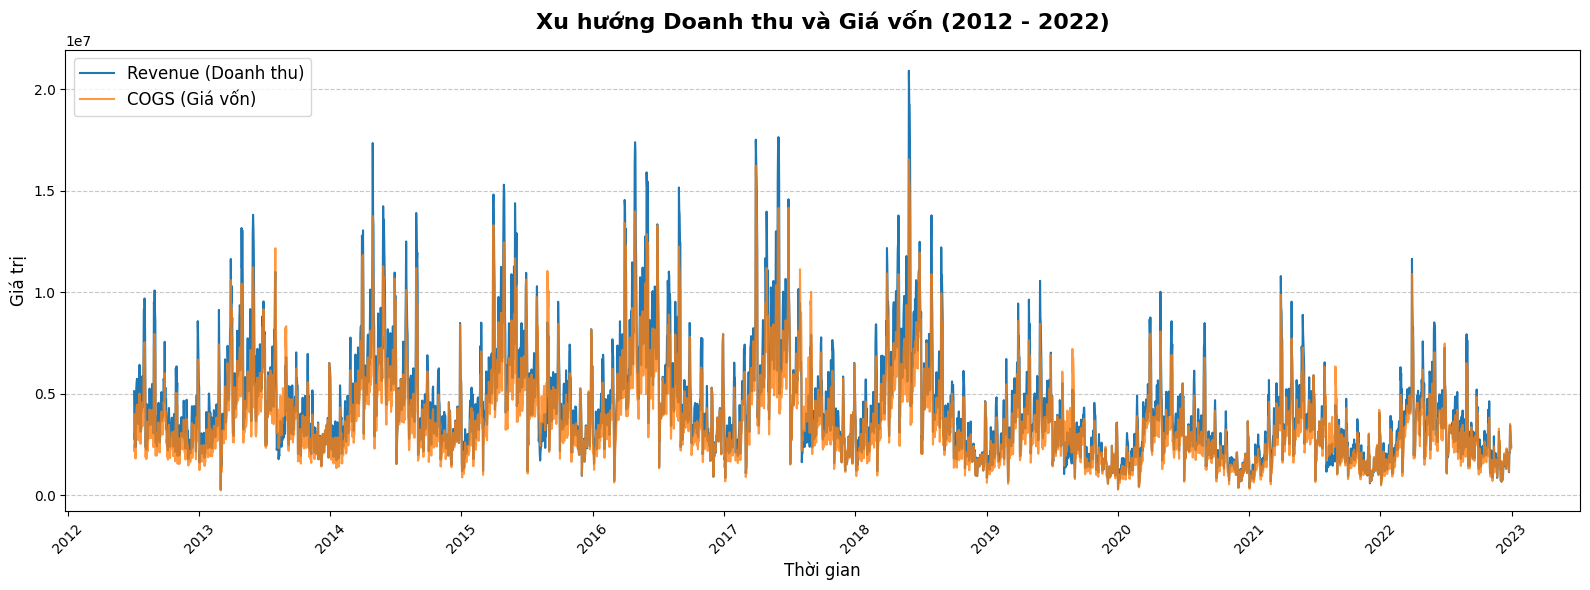

In [4]:
# Trực quan hóa dữ liệu theo chuỗi thời gian
# 1. Đảm bảo cột Date đang ở định dạng thời gian chuẩn
df['date'] = pd.to_datetime(df['date'])

# 2. Thiết lập kích thước biểu đồ (rộng ra để dễ nhìn 10 năm)
plt.figure(figsize=(16, 6))

# 3. Vẽ 2 đường Revenue và COGS
plt.plot(df['date'], df['revenue'], label='Revenue (Doanh thu)', color='#1f77b4', linewidth=1.5)
plt.plot(df['date'], df['cogs'], label='COGS (Giá vốn)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

# 4. Trang trí biểu đồ
plt.title('Xu hướng Doanh thu và Giá vốn (2012 - 2022)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)

# 5. Xử lý trục X để không bị rối mắt (Chỉ hiển thị mốc Năm)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator()) # Chia vạch theo từng năm
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format hiển thị là YYYY
plt.xticks(rotation=45) # Xoay nhãn đi 45 độ

# 6. Thêm lưới, chú thích và căn lề
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

# 7. Hiển thị
plt.show()

<a id ='3'></a>

## 3. Huấn luyện mô hình
Sau khi xem xét tập dữ liệu, chúng tôi đã quyết định xây dựng 2 mô hình cơ sở:
- **Seasonal Navie Model**: Mô hình dự đoán dựa trên quá khứ
- **Linear Regression Model**: Mô hình dự đoán dựa trên các features

Lý do là bởi vì chúng tôi nhận thấy rằng `revenue` cũng sẽ bị ảnh hưởng nhiều bởi nhiều yếu tố như `promotions`, `rating` hay bị biến đổi dựa trên mùa vụ hoặc khoảng thời gian. Vì vậy để tối ưu hóa mô hình, chúng tôi muốn kiểm tra xem liệu thêm những yếu tố bên ngoài vào thì mô hình có cải thiện hay không 

### 3.1 Seasonal Navie Model

In [ ]:
# Đánh giá mô hình Seasonal Naive
seasonal = [7, 30, 30*4, 364] # Các chu kỳ mùa có thể thử
best_result = {}

for s in seasonal:
    val_clean, evaluate = seasonal_naive_model(df, seasonal_length = s)
    if not best_result or evaluate['MAPE'] < best_result['evaluate']['MAPE']:
        best_result = {
            'seasonal_length': s,
            'val_clean': val_clean,
            'evaluate': evaluate
        }

print("--- KẾT QUẢ ĐÁNH GIÁ SEASONAL NAIVE MODEL (BASELINE) ---")
print(f"Chu kỳ mùa tốt nhất: {best_result['seasonal_length']} ngày, tương đương chu kỳ khoảng {best_result['seasonal_length']} ngày.")
print(f"MAE  (Sai số tuyệt đối)   : {best_result['evaluate']['MAE']:,.2f}")
print(f"RMSE (Sai số bình phương) : {best_result['evaluate']['RMSE']:,.2f}")
print(f"MAPE (Sai số phần trăm)   : {best_result['evaluate']['MAPE']:.2f}%")
print(f"R-squared (Độ phù hợp)    : {best_result['evaluate']['R-squared']:.4f}")

--- KẾT QUẢ ĐÁNH GIÁ SEASONAL NAIVE MODEL (BASELINE) ---
Chu kỳ mùa tốt nhất: 364 ngày, tương đương chu kỳ khoảng 364 ngày.
MAE  (Sai số tuyệt đối)   : 859,676.31
RMSE (Sai số bình phương) : 1,243,343.50
MAPE (Sai số phần trăm)   : 27.47%
R-squared (Độ phù hợp)    : 0.4482


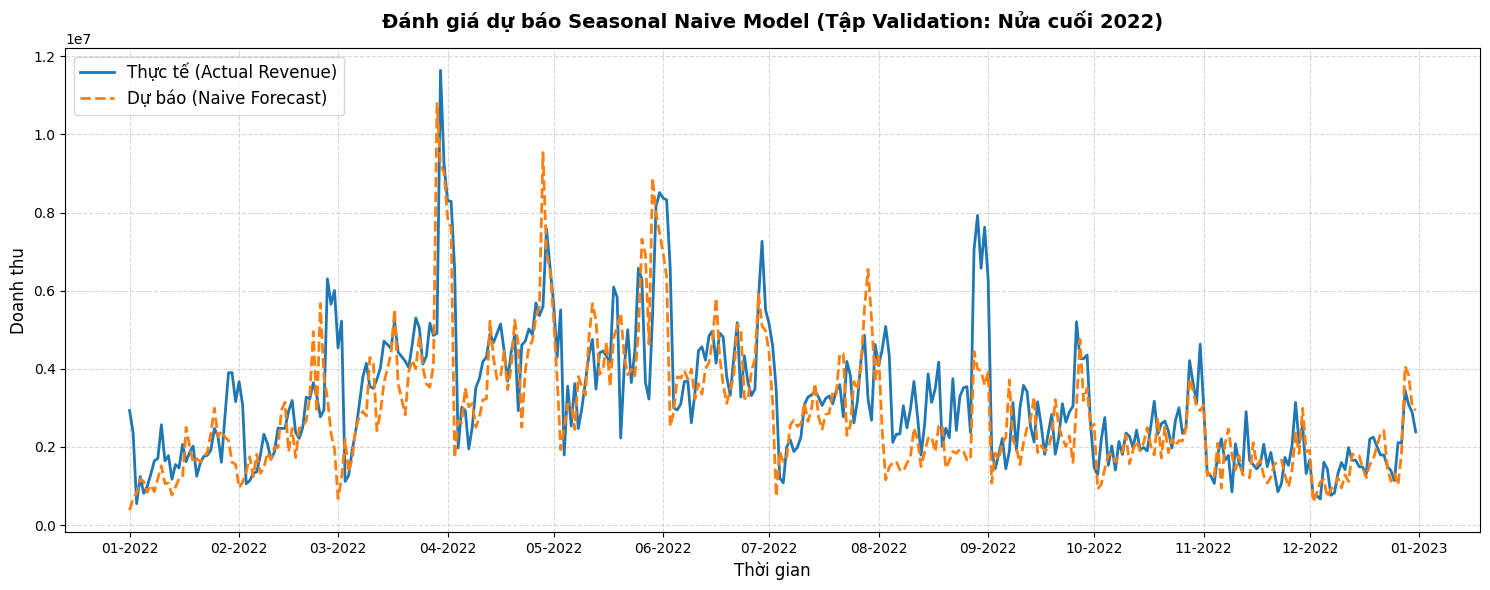

In [6]:
# 1. Thiết lập biểu đồ
plt.figure(figsize=(15, 6))

# 2. Vẽ 2 đường Thực tế và Dự báo trên tập val_clean
plt.plot(val_clean['date'], val_clean['revenue'], label='Thực tế (Actual Revenue)', color='#1f77b4', linewidth=2)
plt.plot(val_clean['date'], val_clean['naive_revenue'], label='Dự báo (Naive Forecast)', color='#ff7f0e', linestyle='--', linewidth=2)

# 3. Trang trí
plt.title('Đánh giá dự báo Seasonal Naive Model (Tập Validation: Nửa cuối 2022)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)

# 4. Xử lý trục X để hiển thị theo từng tháng cho dễ nhìn
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.xticks(rotation=0)

# 5. Thêm lưới và chú thích
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

# 6. Hiển thị
plt.show()

**Kết luận:**

Mô hình seasonal navie model với chu kỳ 1 năm 364 ngày
- `MAE`: 859,676.31
- `RMSE`: 1,243,343.50
- `MAPE`: 27.47%
- `R-squared`: 0.4482

### 3.2 Linear Regression Model

In [11]:
# Cần tạo các Features cơ bản trước khi đưa vào mô hình Baseline
df_baseline = df.copy()
df_baseline['date'] = pd.to_datetime(df_baseline['date'])
df_baseline = df_baseline.sort_values('date').reset_index(drop=True)

# Đặc trưng thời gian tĩnh
df_baseline['day_of_week'] = df_baseline['date'].dt.dayofweek
df_baseline['day_of_month'] = df_baseline['date'].dt.day
df_baseline['month'] = df_baseline['date'].dt.month

# Đặc trưng chu kỳ (Lags) - Đã tìm hiểu ở phần EDA
df_baseline['lag_1'] = df_baseline['revenue'].shift(1)
df_baseline['lag_7'] = df_baseline['revenue'].shift(7)
df_baseline['lag_28'] = df_baseline['revenue'].shift(28)
df_baseline['lag_364'] = df_baseline['revenue'].shift(364)

# Danh sách các biến đầu vào
features = ['day_of_week', 'day_of_month', 'month', 'lag_1', 'lag_7', 'lag_28', 'lag_364']

val_lgbm, _, metrics_lgbm = linear_regression_model(df_baseline, feature_cols=features)

print("\n--- KẾT QUẢ ĐÁNH GIÁ LINEAR REGRESSION MODEL (BASELINE) ---")
print(f"MAE  (Sai số tuyệt đối)   : {metrics_lgbm['MAE']:,.2f}")
print(f"RMSE (Sai số bình phương) : {metrics_lgbm['RMSE']:,.2f}")
print(f"MAPE (Sai số phần trăm)   : {metrics_lgbm['MAPE']:.2f}%")
print(f"R-squared (Độ phù hợp)    : {metrics_lgbm['R-squared']:.4f}")


--- KẾT QUẢ ĐÁNH GIÁ LINEAR REGRESSION MODEL (BASELINE) ---
MAE  (Sai số tuyệt đối)   : 640,996.51
RMSE (Sai số bình phương) : 899,713.69
MAPE (Sai số phần trăm)   : 23.18%
R-squared (Độ phù hợp)    : 0.7111


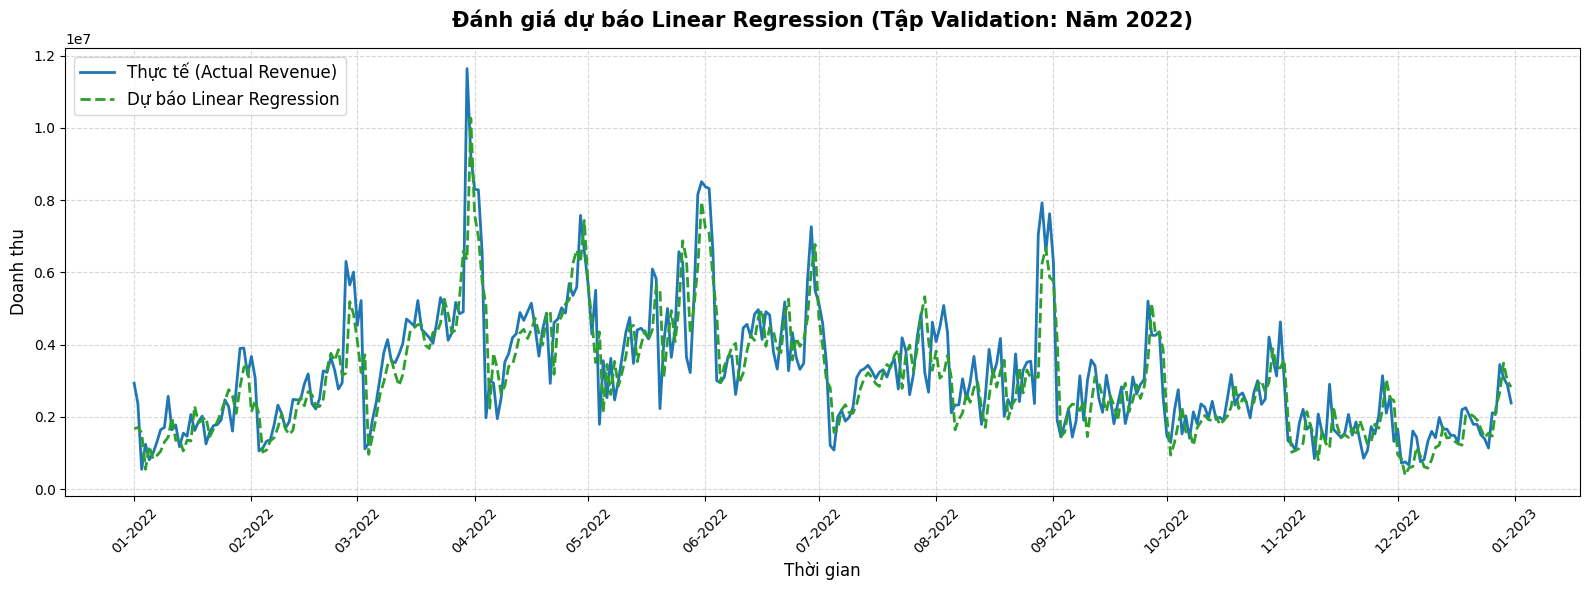

In [12]:
plt.figure(figsize=(16, 6))

# Vẽ 2 đường Thực tế (Màu xanh) và Dự báo LightGBM (Màu xanh lá)
plt.plot(val_lgbm['date'], val_lgbm['revenue'], label='Thực tế (Actual Revenue)', color='#1f77b4', linewidth=2)
plt.plot(val_lgbm['date'], val_lgbm['lr_revenue'], label='Dự báo Linear Regression', color='#2ca02c', linestyle='--', linewidth=2)

# Trang trí tiêu đề và nhãn
plt.title('Đánh giá dự báo Linear Regression (Tập Validation: Năm 2022)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)

# Định dạng trục X hiển thị theo từng tháng
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.xticks(rotation=45) # Xoay 45 độ cho dễ đọc

# Thêm lưới và chú thích
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

**Kết luận:**

Mô hình Linear Regression với các features bao gồm `day_of_week`, `day_of_month`, `month`, `lag_1`, `lag_7`, `lag_30`, `lag_364`    
Dữ liệu tập test là 1 năm cuối

- `MAE`: 640,996.51
- `RMSE`: 899,713.69
- `MAPE`: 23.18%
- `R-squared`: 0.7111

<a id ='4'></a>

## 4. Đánh giá và so sánh

In [14]:
# In kết quả so sánh
print("-" * 55)
print(f"{'CHỈ SỐ':<15} | {'NAIVE (Shift 364)':<20} | {'LINEAR REGRESSION'}")
print("-" * 55)
for key in metrics_lgbm.keys():
    print(f"{key:<15} | {best_result['evaluate'][key]:<20,.2f} | {metrics_lgbm[key]:,.2f}")

-------------------------------------------------------
CHỈ SỐ          | NAIVE (Shift 364)    | LINEAR REGRESSION
-------------------------------------------------------
MAE             | 859,676.31           | 640,996.51
RMSE            | 1,243,343.50         | 899,713.69
MAPE            | 27.47                | 23.18
R-squared       | 0.45                 | 0.71


**Đánh giá Hiệu suất Mô hình Cơ sở (Baseline Evaluation):**

- **Sự vượt trội toàn diện:** Mô hình `Linear Regression` cải thiện tốt trên cả 4 chỉ số so với mô hình `Seasonal Naive`, mô hình này sẽ trở thành mô hình cơ sở cho bài toán dự báo của chúng tôi.

- **Tối ưu hóa các đỉnh doanh thu (RMSE):** Điểm sáng lớn nhất là `RMSE` giảm đáng kể (hơn `400.000` đơn vị). Điều này chứng tỏ thuật toán Cây quyết định xử lý các điểm dị biệt (như các ngày sale đột biến) tốt hơn hẳn so với việc rập khuôn theo chu kỳ của năm trước.

- **Khả năng giải thích dữ liệu (R-squared):** `R-squared` tăng mạnh từ `0.45` lên `0.71`. Việc kết hợp linh hoạt các đặc trưng thời gian (thứ, tháng) và độ trễ đã giúp mô hình nắm bắt được gần `70%` nguyên nhân gây ra sự biến động của dòng tiền.

- **Giới hạn của mô hình hiện tại (MAPE):** Mặc dù sai số tuyệt đối `MAE` đã giảm, sai số phần trăm `MAPE` vẫn dừng ở mức `23.18%`. Đây là đặc điểm chung của các mô hình chỉ sử dụng dữ liệu nội tại (chỉ học từ quá khứ của chính nó).

---
**Kết luận:**

Như vậy, việc sử dụng cả 2 models với cách train khác nhau: `Seasonal Navie Model` - sử dụng dữ liệu từ quá khứ để dự báo cho tương lai và `Linear Regression` - sử dụng các features theo tính chu kỳ đã cho ta thấy rõ được hướng đi tiếp theo là gì. Kết quả đã cho thấy rằng `revenue` có khả năng cao bị phụ thuộc vào nhiều yếu tố khác bên ngoài khác chứ không chỉ còn dựa vào dữ liệu từ quá khứ và các chu kỳ. Do đó hướng đi tiếp theo của chúng tôi sẽ lựa chọn các mô hình dự đoán dựa trên các features thay vì đi sâu vào các mô hình dự đoán truyền thống để tránh làm mất thời gian và kết quả sẽ tốt hơn nhiều.

Công việc tiếp theo:
- **Features Engineering**: Sử dụng các kỹ thuật đặc trưng để tìm ra bộ features tốt nhất dựa trên mô hình cơ sở
- **Models**: Lựa chọn ra mô hình phù hợp nhất và tốt nhất cho bài toán
- **Improve**: Sử dụng một vài phương pháp khác nhau để cải thiện mô hình
---
**Notebooks tiếp theo**: [06_FEATURES_ENGINEER_.ipynb](06_FEATURES_ENGINEER_.ipynb) - Lựa chọn đặc trưng